# BÀI TẬP: EDA HOÀN CHỈNH — TITANIC
## Data Profiling → Descriptive Statistics → Define the Question
**Nguồn:** kaggle.com/c/titanic (891 dòng)

```
PHẦN A — DATA PROFILING       : dữ liệu sạch chưa, có gì
PHẦN B — DESCRIPTIVE STATS    : từng biến trông như thế nào
PHẦN C — DEFINE THE QUESTION  : đặt câu hỏi kinh doanh, trả lời bằng code, rút insight
```

## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [ ]:
# TODO
#kích thước dữ liệu (dòng, cột)
df.shape

(891, 15)

In [3]:
#xem tên tất cả cột 
df.columns
#df.columns.tolist()

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [4]:
#xem kiểu dữ liệu từng cột
df.dtypes

survived         int64
pclass           int64
sex                str
age            float64
sibsp            int64
parch            int64
fare           float64
embarked           str
class              str
who                str
adult_male        bool
deck               str
embark_town        str
alive              str
alone             bool
dtype: object

## A.2. Missing values & Duplicate data

In [10]:
# TODO
#đếm gtri bị thiếu
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [11]:
#kiểm tra các dòng dữ liệu bị trùng
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886     True
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [ ]:
#đếm số dòng bị trùng
df.duplicated().sum()

#Xóa dòng bị trùng và cập nhật lại df
#df = df.drop_duplicates()

np.int64(107)

## A.3. Invalid values

In [ ]:
# TODO
# Ktra các dòng có Age < 0
# df[df["Age"] < 0]
# Ktra các dòng có Age > 100
# df[df["Age"] > 100]

In [4]:
# TODO


## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [13]:
# TODO
#sibsp (anh chị em) + parch (cha mẹ) + 1 (bản thân) = số family
df['family_size'] = df['sibsp'] + df['parch'] + 1
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,1
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,1
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,4
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,1


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [29]:
# TODO
#tính trung bình của các cột số
df[['age','fare','family_size']].mean()

age            29.699118
fare           32.204208
family_size     1.904602
dtype: float64

In [16]:
#thống kê mô tả
df.describe()

,survived,pclass,age,sibsp,parch,fare,family_size
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.904602
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,1.613459
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,2.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000


## Group 2 — Dispersion

In [17]:
# TODO
#tính độ lệch chuẩn
df[['age','fare','family_size']].std()
#thống kê mô tả
df[['age','fare','family_size']].describe()

,age,fare,family_size
count,714.000000,891.000000,891.000000
mean,29.699118,32.204208,1.904602
std,14.526497,49.693429,1.613459
min,0.420000,0.000000,1.000000
25%,20.125000,7.910400,1.000000
50%,28.000000,14.454200,1.000000
75%,38.000000,31.000000,2.000000
max,80.000000,512.329200,11.000000


## Group 3 — Location and Shape

<Axes: xlabel='age', ylabel='Count'>

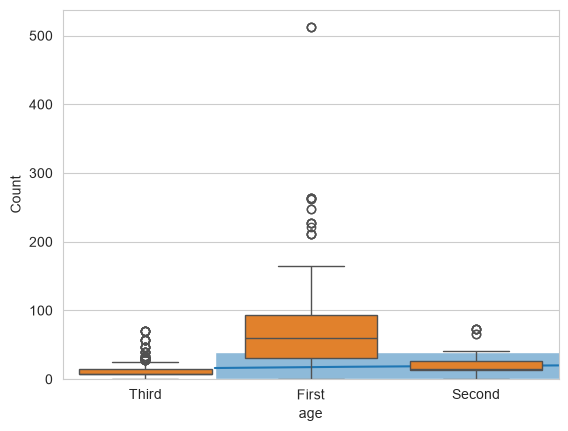

In [18]:
# TODO
#vẽ biểu đồ phân phối của Age
sns.histplot(df['age'], kde=True)
#vẽ boxplot của fare theo class
sns.boxplot(x='class', y='fare', data=df)

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

In [19]:
# TODO
# tính tỷ lệ sống sót theo hạng vé
survival_rate = df.groupby('class')['survived'].mean()
# xem tỷ lệ sống sót
survival_rate

class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64

In [21]:
#tính tỷ lệ sống sót cao nhất và thấp nhất
print("Chênh lệch:",
    survival_rate.max() - survival_rate.min() 
    )

Chênh lệch: 0.3872671041713812


## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

In [22]:
# TODO
#tính tỷ lệ sống sót theo giới tính
df.groupby('sex')['survived'].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

In [23]:
#tính tỷ lệ sống sót theo hạng vé
df.groupby('class')['survived'].mean()

class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64

In [24]:
#thêm:
#so sánh tỷ lệ sống sót theo giới tính và hạng vé
df.groupby(['sex', 'class'])['survived'].mean()

sex     class 
female  First     0.968085
        Second    0.921053
        Third     0.500000
male    First     0.368852
        Second    0.157407
        Third     0.135447
Name: survived, dtype: float64

## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

<Axes: xlabel='fare', ylabel='survived'>

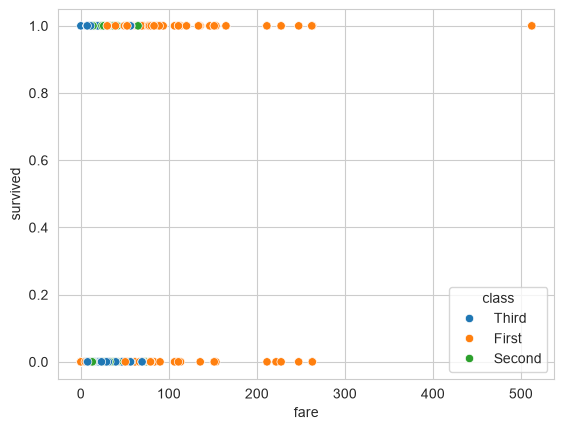

In [25]:
#vẽ mqh giữa giá vé và sống sót
sns.scatterplot(x='fare', y='survived', hue='class', data=df)

## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

In [26]:
# TODO
#tính tỷ lệ sống sót theo quy mô gia đình
df.groupby('family_size')['survived'].mean()

family_size
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: survived, dtype: float64

In [27]:
#thêm:
#so sánh quy mô gia đình và tỷ lệ sống sót
df.groupby('family_size')['survived'].agg(['mean', 'count'])

,mean,count
family_size,,
1,0.303538,537
2,0.552795,161
3,0.578431,102
4,0.724138,29
5,0.200000,15
6,0.136364,22
7,0.333333,12
8,0.000000,6
11,0.000000,7


## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

In [28]:
# TODO
#tính tỷ lệ sống sót theo cảng lên tàu
df.groupby('embark_town')['survived'].mean()

embark_town
Cherbourg      0.553571
Queenstown     0.389610
Southampton    0.336957
Name: survived, dtype: float64

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

*(Viết insight của bạn vào đây...)*